In [2]:
%matplotlib inline
import matplotlib.pyplot as plt

import numpy as np
import sys
from enterprise_warp import enterprise_warp

import Morph as morph
import read_pta as read_pta
# ─── Monkey-patch EntryPoint.default_kwargs ────────────────────────────────────
try:
    import entrypoints
    entrypoints.EntryPoint.default_kwargs = property(
        lambda self: getattr(self.load(), "__kwdefaults__", {}) or {}
    )
except ImportError:
    pass

try:
    # In case enterprise_warp is using importlib.metadata.EntryPoint instead
    import importlib.metadata as _im
    _im.EntryPoint.default_kwargs = property(
        lambda self: getattr(self.load(), "__kwdefaults__", {}) or {}
    )
except (ImportError, AttributeError):
    pass
# ────────────────────────────────────────────────────────────────────────────────
%matplotlib inline

import corner
import ppta_dr2_models as ppta_dr2_models


MPI startup(): FI_PSM3_UUID was not generated, please set it to avoid possible resources ownership conflicts between MPI processes


/home/ezahraou/.local/lib/python3.10/site-packages/enterprise_warp-0.0.2-py3.10.egg/enterprise_warp/results.py:32: UserWarning: ChainConsumer is not available


In [3]:
# keep only the script name
sys.argv = sys.argv[:1]

path_par = "/fred/oz103/ezahraoui/PPTA/run_wrap/sampling_params/ppta_pol_7psr_byband_noeccorequad.dat"
#opts = enterprise_warp.parse_commandline()
opts = enterprise_warp.parse_commandline()

custom = ppta_dr2_models.PPTADR2Models
params = enterprise_warp.Params(path_par,opts=opts,custom_models_obj=custom)


------------------
Setting default parameters with file  /fred/oz103/ezahraoui/PPTA/run_wrap/sampling_params/ppta_pol_7psr_byband_noeccorequad.dat
Setting default Solar System Ephemeris: DE438
Only using pulsars from psrlist
Setting a default linear timing model
Setting timing model SVD to 0 (False)
Including transient events to specific pulsar models
Setting reference radio frequency to 1400 MHz
------------------
Setting sampler kwargs from the parameter file:
------------------
Number of .par files:  25
Number of .tim files:  25
Loading pulsars
[tempo2Util.C:396] Warning: [TIM1] Please place MODE flags in the parameter file 
[tempo2Util.C:401] Warning: [DUP1] duplicated warnings have been suppressed.


Pol calibration is set to True
Adding polynomial distortion vec to pulsars


In [4]:
pta = enterprise_warp.init_pta(params)

GWB/CPL options:  pol_dist_30_nfreqs
Number of Fourier frequencies for the GWB/CPL signal:  30
Adding polynomial distortion ORF
returned pol: 
Using noise parameters from the file:  {'J0711-6830_CASPSR_40CM_efac': 1.1298258736280822, 'J0711-6830_CASPSR_40CM_log10_equad': -7.6299166849010085, 'J0711-6830_CPSR2_20CM_efac': 1.064084985404349, 'J0711-6830_CPSR2_20CM_log10_equad': -6.04717097779411, 'J0711-6830_CPSR2_50CM_efac': 1.0940590289422412, 'J0711-6830_CPSR2_50CM_log10_equad': -7.731224036363758, 'J0711-6830_PDFB1_10CM_efac': 0.9877037281298511, 'J0711-6830_PDFB1_10CM_log10_equad': -5.21005052309488, 'J0711-6830_PDFB1_1433_efac': 1.092925238127751, 'J0711-6830_PDFB1_1433_log10_equad': -7.755054181029302, 'J0711-6830_PDFB1_20CM_efac': 1.082837868905749, 'J0711-6830_PDFB1_20CM_log10_equad': -8.07792126238142, 'J0711-6830_PDFB1_early_10CM_efac': 0.9638568848852437, 'J0711-6830_PDFB1_early_10CM_log10_equad': -5.280023683036845, 'J0711-6830_PDFB1_early_20CM_efac': 0.9999217999305334, 'J0

In [5]:
chainDIR = '/fred/oz103/ezahraoui/PPTA/ppta_posteriors/noeccorequad_7_psr_pol_cal_by_band_allpsr/0'
pars = np.genfromtxt(chainDIR+'/pars.txt',dtype=str,unpack=True)

burn = 10000

post_raw = read_pta.read_pt_post_eval(chainDIR,burn_in=burn)

pst_raw = read_pta.read_post_pt(chainDIR ,pars,burn_in=burn)


Calibrating using chains from file chain_1.txt
len post: 7544
Calibrating using chains from file chain_1.txt
Number of dimensions : 53
Posterior samples imported


In [6]:
import Morph as morph
import numpy as np
from scipy.stats import norm
from scipy.optimize import brentq, minimize_scalar

# ------------------------------------------------------------------ helpers
def _lscv_objective(h, x):
    n     = len(x)
    diff  = (x[:, None] - x[None, :]) / h
    K     = norm.pdf(diff) / h
    np.fill_diagonal(K, 0.0)          # leave‑one‑out
    f_loo = K.sum(axis=1) / (n - 1)
    return -np.mean(np.log(f_loo + 1e-300))

def _lscv_bandwidth(x):
    """Least‑squares CV bandwidth (1‑D)."""
    n     = len(x)
    std   = np.std(x, ddof=1)
    h_min = std * n**-0.6             # lower bound
    h_max = std                       # upper bound

    # Derivative of LSCV objective wrt h
    def dLdh(h):
        diff  = (x[:, None] - x[None, :]) / h
        K0    = norm.pdf(diff)
        K2    = (diff**2 - 1) * K0 / h
        np.fill_diagonal(K2, 0.0)
        term1 = -2 * K2.sum() / (n * (n - 1) * h)
        term2 =  2 * K0.sum() / (n * (n - 1) * h**2)
        return term1 + term2

    # ---------- try root‑finding on derivative ----------
    try:
        if np.sign(dLdh(h_min)) == np.sign(dLdh(h_max)):
            raise ValueError("root not bracketed")
        h_opt = brentq(dLdh, h_min, h_max, maxiter=50)
    except Exception:
        # ---------- fallback: direct minimisation ----------
        res   = minimize_scalar(
            _lscv_objective,
            bounds=(h_min, h_max),
            method="bounded",
            args=(x,)               # <-- pass the sample here
        )
        h_opt = res.x
    return h_opt

# ------------------------------------------------------------------ main API
def optimal_bandwidths(samples, method="sj"):
    """
    Per‑coordinate bandwidths for product‑KDE proposal.

    Parameters
    ----------
    samples : ndarray, shape (N, d)
    method  : {"sj", "lscv", "silverman", "scott"}

    Returns
    -------
    h : ndarray, shape (d,)
    """
    samples = np.asarray(samples)
    N, d    = samples.shape
    h       = np.empty(d)

    for j in range(d):
        x = samples[:, j]

        if method == "sj":
            try:
                from statsmodels.nonparametric.kde import KDEUnivariate
                kde = KDEUnivariate(x)
                kde.fit(kernel="gau", bw="sj")
                h[j] = float(kde.bw)
                continue
            except Exception:
                method = "lscv"      # graceful downgrade

        if method == "lscv":
            h[j] = _lscv_bandwidth(x)
        elif method == "silverman":
            iqr   = np.subtract(*np.percentile(x, [75, 25]))
            sigma = np.std(x, ddof=1)
            h[j] = 0.9 * min(sigma, iqr / 1.34) * N ** (-1/5)
        elif method == "scott":
            h[j] = np.std(x, ddof=1) * N ** (-1/5)
        else:
            raise ValueError("Unknown method '{}'".format(method))

    return h


In [7]:
samples_raw.shape

NameError: name 'samples_raw' is not defined

In [ ]:
from numpy.fft import fft, ifft
import numpy as np
import numpy as np

def bandwidth_iqr(samples):
    """
    Fast rule-of-thumb bandwidths for product-KDE.

    Parameters
    ----------
    samples : (N, d) array of posterior draws

    Returns
    -------
    h : (d,) array
    """
    n      = samples.shape[0]
    sigma  = samples.std(axis=0, ddof=1)
    iqr    = np.subtract(*np.percentile(samples, [75, 25], axis=0))
    scale  = np.minimum(sigma, iqr / 1.349)          # 1.349 ≈ Φ⁻¹(.75) − Φ⁻¹(.25)
    return 1.06 * scale * n ** (-1/5)                # Silverman factor 1.06

def bandwidth_iqr_only(samples, c=0.9):
    """
    Robust IQR‑based bandwidths for a product‑of‑marginals KDE.

    Parameters
    ----------
    samples : ndarray, shape (N, d)
        Posterior draws.
    c       : float, optional (default 0.9)
        Constant multiplier (pick 1.06 to mimic Silverman’s σ‑rule;
        keep 0.9 if you want a directly comparable scale factor).

    Returns
    -------
    h : ndarray, shape (d,)
        Bandwidth for each marginal.
    """
    samples = np.asarray(samples)
    n, _    = samples.shape

    # 25th and 75th percentiles for each dimension (vectorised)
    q25, q75 = np.percentile(samples, [25, 75], axis=0)
    iqr      = q75 - q25

    # Convert IQR to σ‑equivalent under Normal: divide by 1.349
    robust_sd = iqr / 1.349

    # Plug into rule‑of‑thumb h = c * σ̂ * n^(-1/5)
    return c * robust_sd * n ** (-1/5)

def botev_bandwidth(x):
    """Botev et al. (2010) plug‑in bandwidth for a 1‑D sample."""
    x      = (x - x.min()) / (x.max() - x.min())     # rescale to [0,1]
    n      = len(x)
    N      = 2 ** 14                                 # power of two grid
    a      = np.histogram(x, bins=N, range=(0, 1))[0] / n
    a      = np.concatenate((a, np.zeros(N)))        # zero‑pad
    ft     = fft(a) ** 2
    I      = np.arange(1, N) ** 2
    t_star = (2 * np.pi) ** (1/3) * (sum(I ** 2 * ft[1:N]).real /
              (n * (sum(I * ft[1:N]).real) ** 1.5)) ** (1/5)
    h      = np.sqrt(t_star) * (x.max() - x.min())   # rescale back
    return h

def bandwidth_botev_all(samples):
    return np.array([botev_bandwidth(samples[:, j]) for j in range(samples.shape[1])])


In [10]:
posterior_samples = samples_raw.T    # (N, d) array
bw_botev = bandwidth_botev_all(posterior_samples)  # vector of h_j
bw_iqr = bandwidth_iqr(posterior_samples)  # vector of h_j
bw_iqr_only = bandwidth_iqr_only(posterior_samples)  # vector of h_j
for i in range(10,20):
   print(f'Botev bandwidths: {bw_botev[i]}, IQR bandwidths: {bw_iqr[i]}, IQR only bandwidths: {bw_iqr_only[i]}')


Botev bandwidths: nan, IQR bandwidths: 0.04089952958307077, IQR only bandwidths: 0.03472601568373933
Botev bandwidths: 2.246491385054844, IQR bandwidths: 0.011824532958905162, IQR only bandwidths: 0.010039697795296837
Botev bandwidths: 2.1337521525296155, IQR bandwidths: 0.11319395856444193, IQR only bandwidths: 0.09610807802641297
Botev bandwidths: 2.252708360038423, IQR bandwidths: 0.02184336039641936, IQR only bandwidths: 0.018546249393186248
Botev bandwidths: nan, IQR bandwidths: 0.00465920246675389, IQR only bandwidths: 0.003955926622715567
Botev bandwidths: 2.2503674516339323, IQR bandwidths: 0.004732186588904393, IQR only bandwidths: 0.004036373972846402
Botev bandwidths: nan, IQR bandwidths: 0.00587738323554152, IQR only bandwidths: 0.004990231049044686
Botev bandwidths: 2.053906778563431, IQR bandwidths: 0.08624769949390684, IQR only bandwidths: 0.07322917881558129
Botev bandwidths: 2.2516779510948983, IQR bandwidths: 0.029423773137030273, IQR only bandwidths: 0.02498244888993

/tmp/ipykernel_2386219/1253485917.py:62: RuntimeWarning: invalid value encountered in scalar power
/tmp/ipykernel_2386219/1253485917.py:63: RuntimeWarning: invalid value encountered in scalar power


In [15]:
print(pta[0].param_names)
samples_raw = read_pta.dens_evaluate(pst_raw)

def ln_post(teta):
    return pta[0].get_lnlikelihood(teta) + pta[0].get_lnprior(teta)

cut_l = 1
cut_r = -1

thin = 10

samples_thin = samples_raw[:,cut_l:cut_r]
samples = samples_thin[:,::thin].T

log_prob = post_raw[cut_l:cut_r]
log_prob = log_prob[::thin]

tot_len , ndim = samples.shape
print(f'Ncal {tot_len} Ndim {ndim}')
N_new = 2000
target_kde = morph.KDE_approx(samples[:int(tot_len/2),:],bw="silverman")
#target_kde = KDEpyApproxFFT(samples[:int(tot_len/2),:], bw="silverman", param_names=pta[0].param_names)

samples_prop = target_kde.resample(N_new)
#samples_prop = target_kde.resample(N_new, random_state=42)

print(f'Resampled {samples_prop.shape}')
log_prop = target_kde.logpdf_kde(samples_prop)
#log_prop = kde.logpdf(samples_prop)

print(f'logpdf Resampled {len(log_prop)}')

samples_mor = samples[int(tot_len/2):,:]
log_post = log_prob[int(tot_len/2):]
print(samples_mor.shape)

#log_p_estimate , log_z = bridge_sampling_ln(ln_post, target_kde.logpdf_kde, samples_mor,log_post, samples_prop)
log_z_Mor , log_z = morph.bridge_sampling_ln(ln_post, target_kde.logpdf_kde, samples_mor,log_post, samples_prop,tol=1e-4,max_iter=40000)

#print(f'\nlog_p_estimate:{log_z_Mor[0]- 0.5*tot_toa*np.log(2*np.pi)} +\- {log_z_Mor[1]}')

['J0711-6830_10CM_efac', 'J0711-6830_20CM_efac', 'J0711-6830_40CM_efac', 'J0711-6830_dm_gp_gamma', 'J0711-6830_dm_gp_log10_A', 'J0711-6830_red_noise_gamma', 'J0711-6830_red_noise_log10_A', 'J1017-7156_10CM_efac', 'J1017-7156_20CM_efac', 'J1017-7156_40CM_efac', 'J1017-7156_chromatic_gp_gamma', 'J1017-7156_chromatic_gp_log10_A', 'J1017-7156_red_noise_gamma', 'J1017-7156_red_noise_log10_A', 'J1022+1001_10CM_efac', 'J1022+1001_20CM_efac', 'J1022+1001_40CM_efac', 'J1022+1001_dm_gp_gamma', 'J1022+1001_dm_gp_log10_A', 'J1022+1001_red_noise_gamma', 'J1022+1001_red_noise_log10_A', 'J1446-4701_10CM_efac', 'J1446-4701_20CM_efac', 'J1446-4701_40CM_efac', 'J1446-4701_dm_gp_gamma', 'J1446-4701_dm_gp_log10_A', 'J1446-4701_red_noise_gamma', 'J1446-4701_red_noise_log10_A', 'J1730-2304_10CM_efac', 'J1730-2304_20CM_efac', 'J1730-2304_40CM_efac', 'J1730-2304_dm_gp_gamma', 'J1730-2304_dm_gp_log10_A', 'J1730-2304_red_noise_gamma', 'J1730-2304_red_noise_log10_A', 'J1832-0836_10CM_efac', 'J1832-0836_20CM_efac

/fred/oz002/ezahraoui/.conda/envs/nanograv_2/lib/python3.10/site-packages/enterprise/signals/parameter.py:70: RuntimeWarning: divide by zero encountered in log


 Iteration 2000 out of 2000
1422 surviving proposal samples out of 2000

 Computing initial log p(y) using proposal samples initial guess:151159.60030912873
Bridging
 iteration: 5 log(z): 151161.2557061819 +/-: nan(z) New: 151161.25570618198

/fred/oz103/ezahraoui/PPTA/run_wrap/Morph.py:226: RuntimeWarning: overflow encountered in exp
/fred/oz103/ezahraoui/PPTA/run_wrap/Morph.py:273: RuntimeWarning: invalid value encountered in scalar divide


Mean oscill: 151664.37148443217
Err oscill 0.13092075078748167
std oscill 0.03760340528392669
error 0.009321498946519569


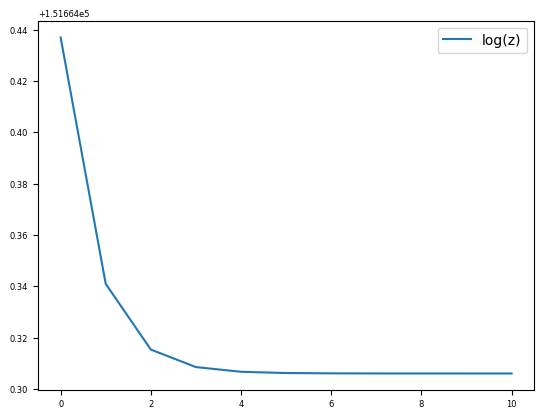

In [58]:

ll = int(0.2*len(log_z))
plt.plot(log_z[ll:],label='log(z)')
plt.legend()
print("Mean oscill:",(log_z[ll:].max()+log_z[ll:].min())/2)
print("Err oscill",(log_z[ll:].max()-log_z[ll:].min()))
print("std oscill",(log_z[ll:]).std())
print("error",morph.error_bound_from_oscillation(log_z[ll:]))


In [ ]:
### Marginal likelihoods 

## 7 psr by band one gamma fast svd iteration: 4 log(z): 147986.37 +/-: 0.062 GSS_8T 147984.32
## 7 psr by band one gamma iteration: 151685.88 +/-: 0.103 GSS_8T 151689.60
## 7 psr by band 3 gamma iteration:  151688.08 +/-: 0.19 GSS_8T 151693.38
## 7 psr by band irn only :   151697.05     GSS_8T 151693.907995
## 7 psr by band curn only :  151691.30 +/-: 0.036  GSS_8T 151692.75095
## 7 psr by backend irn : 151665.54 +/-: 0.06 GSS_8T 151696.79


In [30]:
np.mean([1.51718348729222e+05,
1.51719444585206e+05,
1.51718535588397e+05,
1.51715825185115e+05,
1.51719793298015e+05,
1.51717824913150e+05,
1.51727650738469e+05,
1.51711443883652e+05])

151718.60836515325

In [ ]:
kde_multi = gaussian_kde(samples.T)  # shape must be (d, N)
samples_prop_multi = kde_multi.resample(1000).T
log_g = kde_multi.logpdf(samples_prop_multi.T)
log_g.shape


NameError: name 'gaussian_kde' is not defined

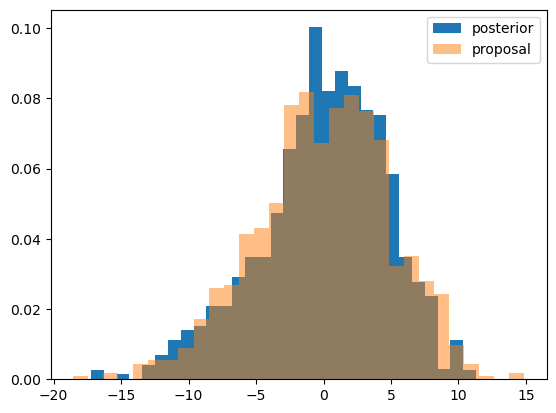

In [12]:
plt.hist(log_prob-log_prob.mean(), bins=30, density=True, label='posterior')
plt.hist(log_prop-log_prop.mean(), bins=30,alpha=0.5, density=True, label='proposal')
plt.legend()

In [52]:
samples_prop_multi.shape

(1000, 134)

NameError: name 'samples_prop_multi' is not defined

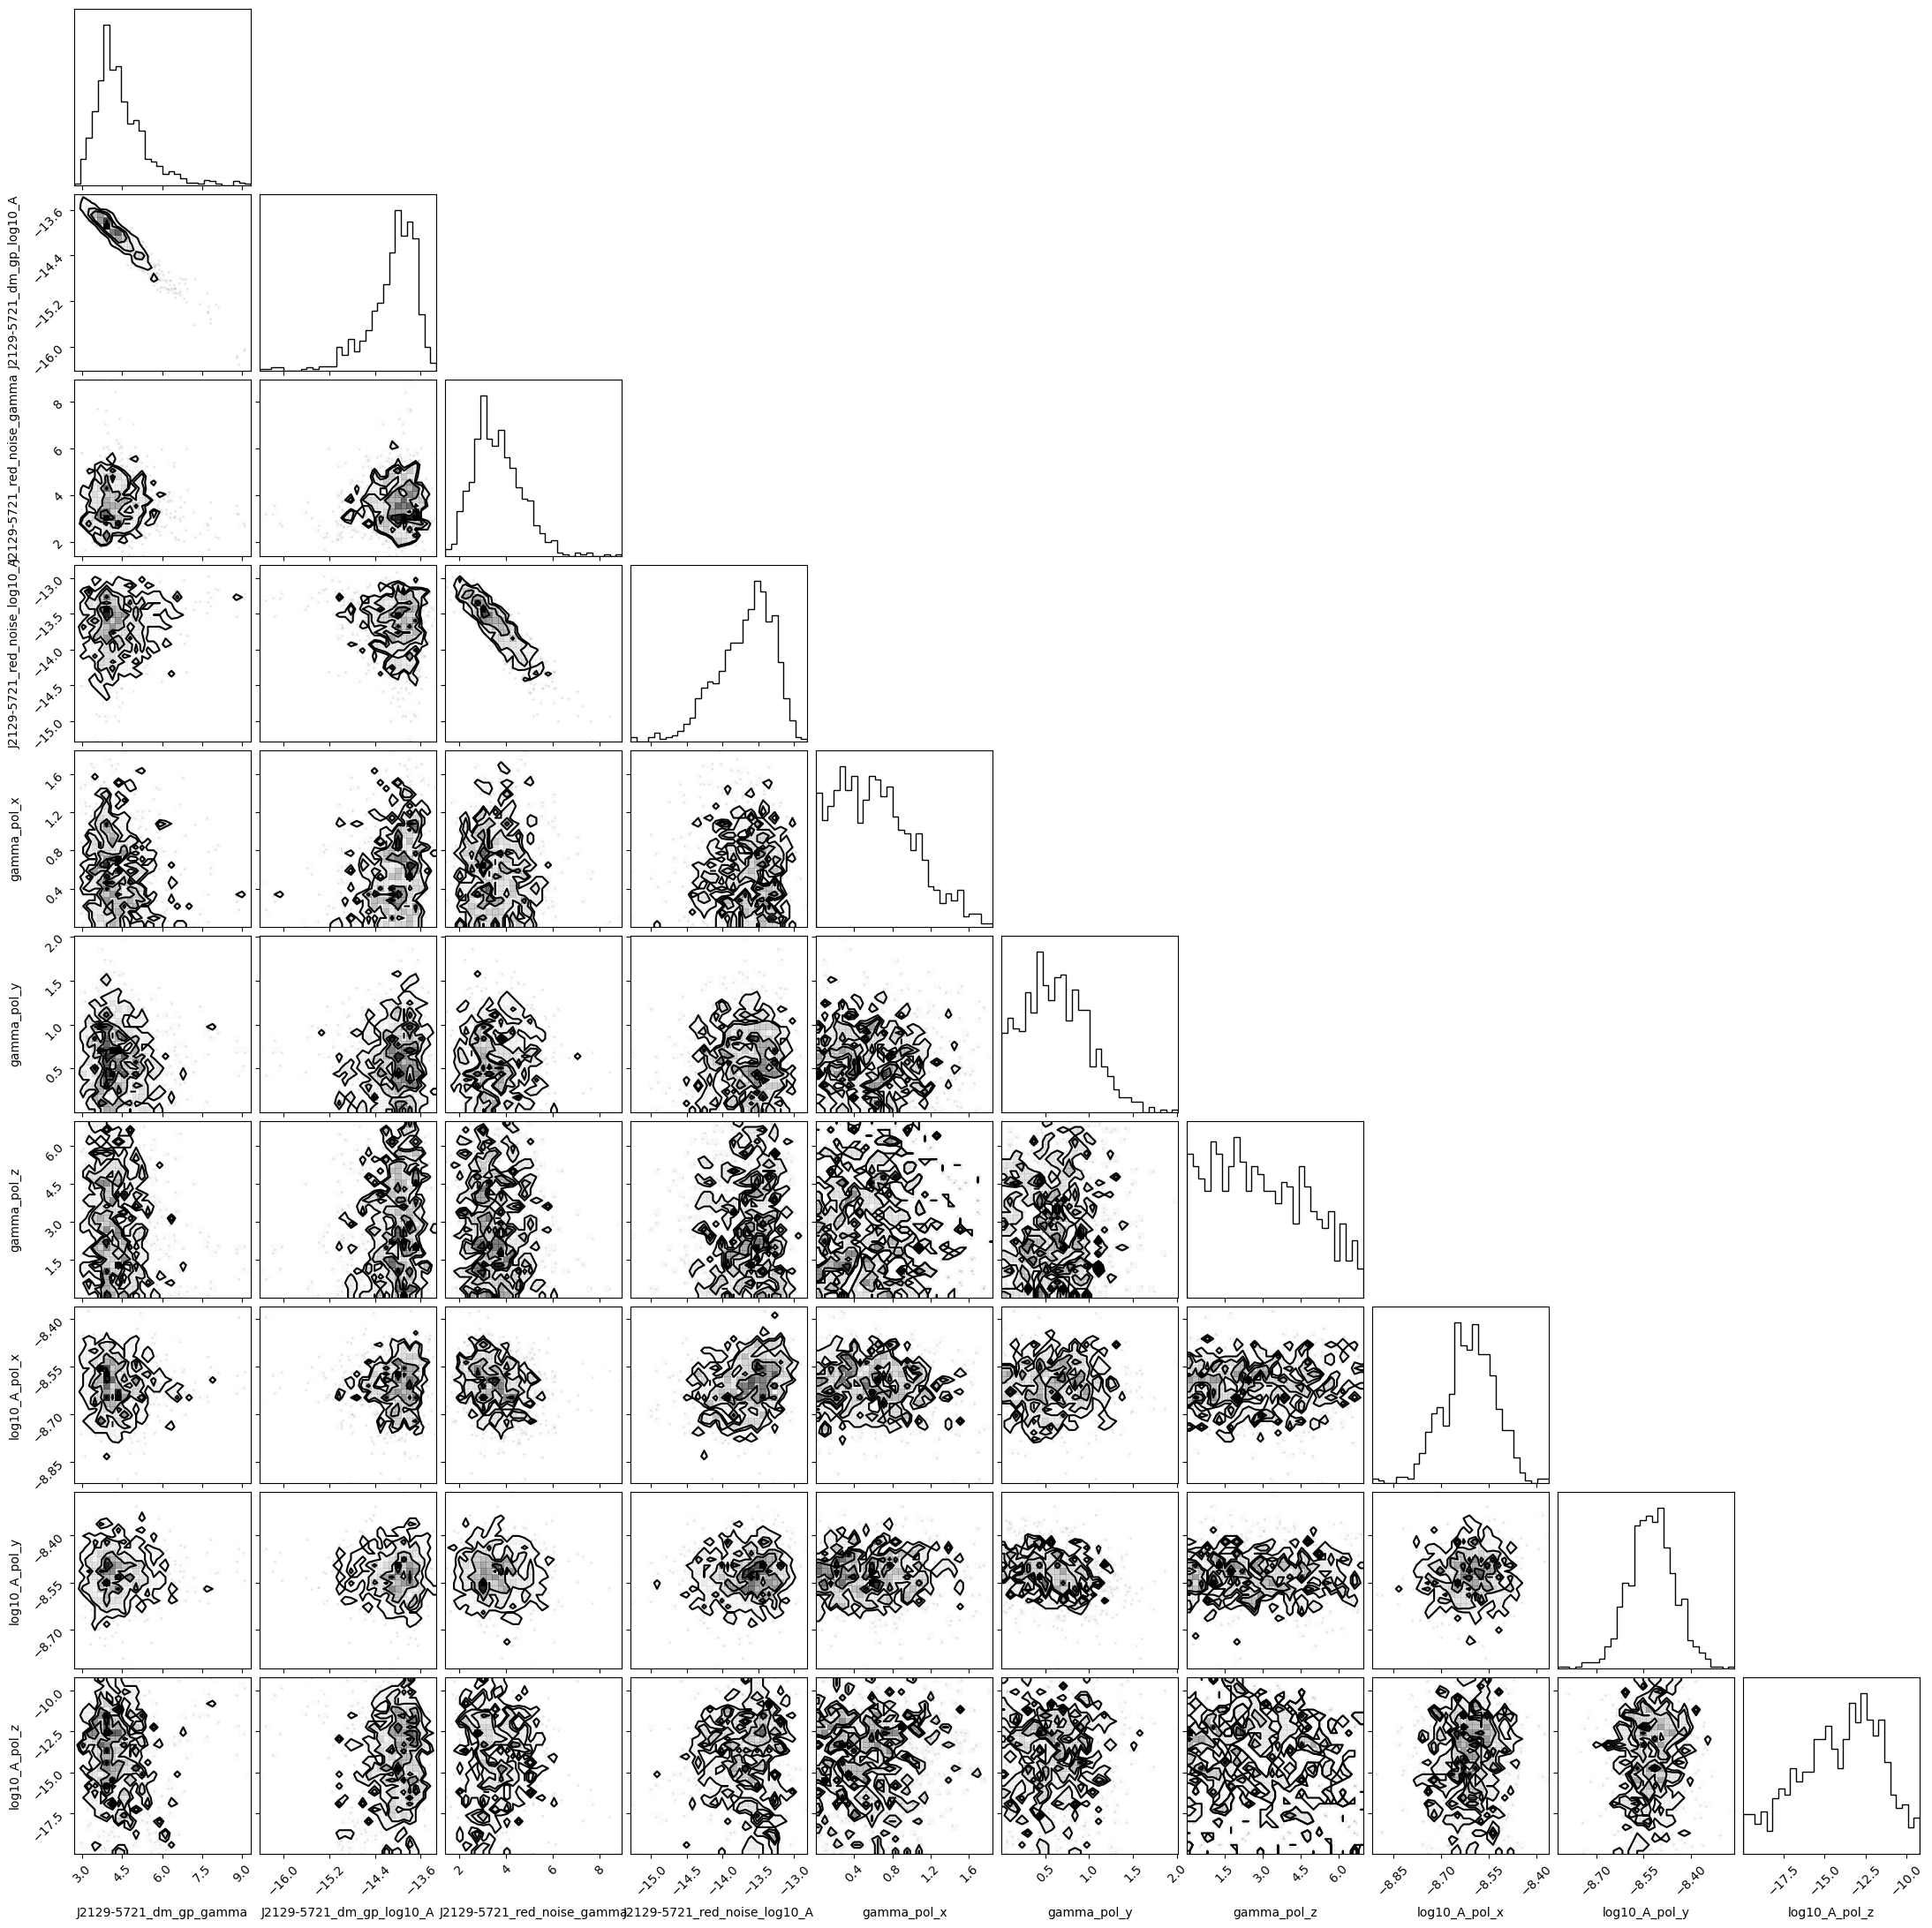

In [13]:
i = -10
param = pars[i:]

fig = corner.corner(samples[:N_new,i:], bins=30, color='black',labels=param, hist_kwargs=dict(density=True))
# corner.corner(samples_prop[i:,:].T, bins=30, color='blue',labels=param,fig=fig, hist_kwargs=dict(density=True))
corner.corner(samples_prop_multi[:,i:], bins=30, color='red',labels=param,fig=fig, hist_kwargs=dict(density=True))
plt.plot([], [], color='black', label='Posterior')
plt.plot([], [], color='blue', label='Proposal')
plt.plot([], [], color='red', label='Multi KDE')
plt.legend(loc='upper left', fontsize=8)
plt.rcParams.update({'xtick.labelsize': 6, 'ytick.labelsize': 6})
plt.show()

# plt.hist(samples[:,i], bins=30, density=True, label='samples')
# #plt.hist(samples_prop[i,:], bins=30, density=True,alpha=0.5, label='proposal samples')
# plt.hist(samples_new[:,i], bins=30, density=True,alpha=0.5, label='new samples')
# plt.legend()


In [ ]:
covv = np.cov(samples.T)
print("Covariance matrix shape:", np.exp(covv))
plt.imshow(covv, cmap='hot', interpolation='nearest')

In [ ]:
284124.785421236-283728.18 

In [ ]:
%matplotlib inline

plt.plot(1,11,'o',label='IRN',color='red')


In [ ]:
print(pta[0].param_names)
N_new = 5000
target_kde = KDE_approx(samples)

mu0 = np.mean(samples,axis=0)
sig0s = np.std(samples,axis=0)

def log_z(x):
    return pta[0].get_lnlikelihood(x)+pta[0].get_lnprior(x)-target_kde.logpdf_kde(x)

new_post_sci = np.zeros(N_new)
save_teta = np.zeros((ndim,N_new))
pi_sci_mcmc = np.zeros(N_new)
rejec_teta = np.zeros((ndim,N_new))
rejec_prob = np.zeros(N_new)

#mean_teta0 = np.mean(new_samp_sci, axis=1)
#P_teta = pta[0].get_lnlikelihood(mean_teta0)+pta[0].get_lnprior(mean_teta0)
teta = target_kde.resample()
#teta = mu0

P_teta = log_z(teta)
save_pi = target_kde.logpdf_kde(teta)

while (P_teta  == -np.inf or P_teta  == np.nan):
    teta = target_kde.resample()
    P_teta = log_z(teta)

new_post_sci[0] = P_teta.item()
pi_sci_mcmc[0] = target_kde.logpdf_kde(teta).item()
save_teta[:,0] = teta
rejec_teta[:,0] = teta
#new_teta  = target_kde.resample(N_new)
#new_teta = mu0
for i in range(1,N_new):
  
  
  try:
    #P_new = pta[0].get_lnlikelihood(new_teta)+pta[0].get_lnprior(new_teta)
    #new_teta = teta + norm.rvs(loc = np.zeros(len(mu0)), scale=sig0s)
    new_teta = target_kde.resample()

    P_new = log_z(new_teta)
  except:
        # Skip iteration if an error occurs
        pass

  alpha = min(0, P_new - P_teta)
                    
  u = np.log(np.random.rand(1))
  print(f"\rIteration {i+1} , acceptance ratio:{(len(np.unique(new_post_sci))-1)/i} , log_z : {read_pta.log_sum(new_post_sci[:i])-np.log(len(new_post_sci[:i]))} ", end="")

            
  if (u < alpha):
    P_teta = P_new
    teta  = new_teta
    save_pi = target_kde.logpdf_kde(new_teta).item()

  new_post_sci[i] = P_teta.item()
  pi_sci_mcmc[i] = save_pi
  save_teta[:,i] = teta
  rejec_prob[i] = P_new.item()
  #rejec_teta[:,i] = new_teta
